# BBox 可视化验证

随机选择一个 val 图片 ID，对比三种视图：
1. 所有小图（切片）的标注 bbox
2. 合成大图上还原的 bbox
3. 原图的 Ground Truth bbox


In [25]:
import json
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [26]:
# 路径配置
INDEX_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd-resized/val/index")
SLICED_IMAGES_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd-resized/val/images")
SLICED_LABELS_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd-resized/val/labels")
ORIGINAL_IMAGES_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd/val/images")
ORIGINAL_LABELS_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd/val/labels")

def load_yolo_labels(label_path: Path) -> list:
    """加载 YOLO 格式标注 (cls, cx, cy, w, h) normalized"""
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]
    labels = []
    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        cx, cy, w, h = map(float, parts[1:5])
        labels.append((cls_id, cx, cy, w, h))
    return labels

def yolo_to_xyxy(cx, cy, w, h, img_w, img_h):
    """YOLO normalized -> xyxy absolute"""
    x1 = (cx - w / 2) * img_w
    y1 = (cy - h / 2) * img_h
    x2 = (cx + w / 2) * img_w
    y2 = (cy + h / 2) * img_h
    return x1, y1, x2, y2

def draw_bboxes(ax, image, labels, img_w, img_h, colors=None):
    """在 ax 上绘制图片和 bbox"""
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    if colors is None:
        colors = plt.cm.tab10.colors
    for cls_id, cx, cy, w, h in labels:
        x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, w, h, img_w, img_h)
        color = colors[cls_id % len(colors)]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, str(cls_id), fontsize=8, color=color, fontweight='bold')
    ax.axis('off')


In [27]:
# 随机选择一个 image_id
index_files = list(INDEX_DIR.glob("*.json"))
selected_file = random.choice(index_files)
image_id = selected_file.stem

with open(selected_file, "r") as f:
    index_data = json.load(f)

print(f"Selected Image ID: {image_id}")
print(f"Original Shape: {index_data['original_shape']} (H x W)")
print(f"Number of Slices: {len(index_data['slices'])}")


Selected Image ID: fully_val_ZlDl12kyagr_pxxJTs40AQ
Original Shape: [2160, 4096] (H x W)
Number of Slices: 8


/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1993231297.py:46: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1993231297.py:46: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1993231297.py:46: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1993231297.py:46: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1993231297.py:46: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


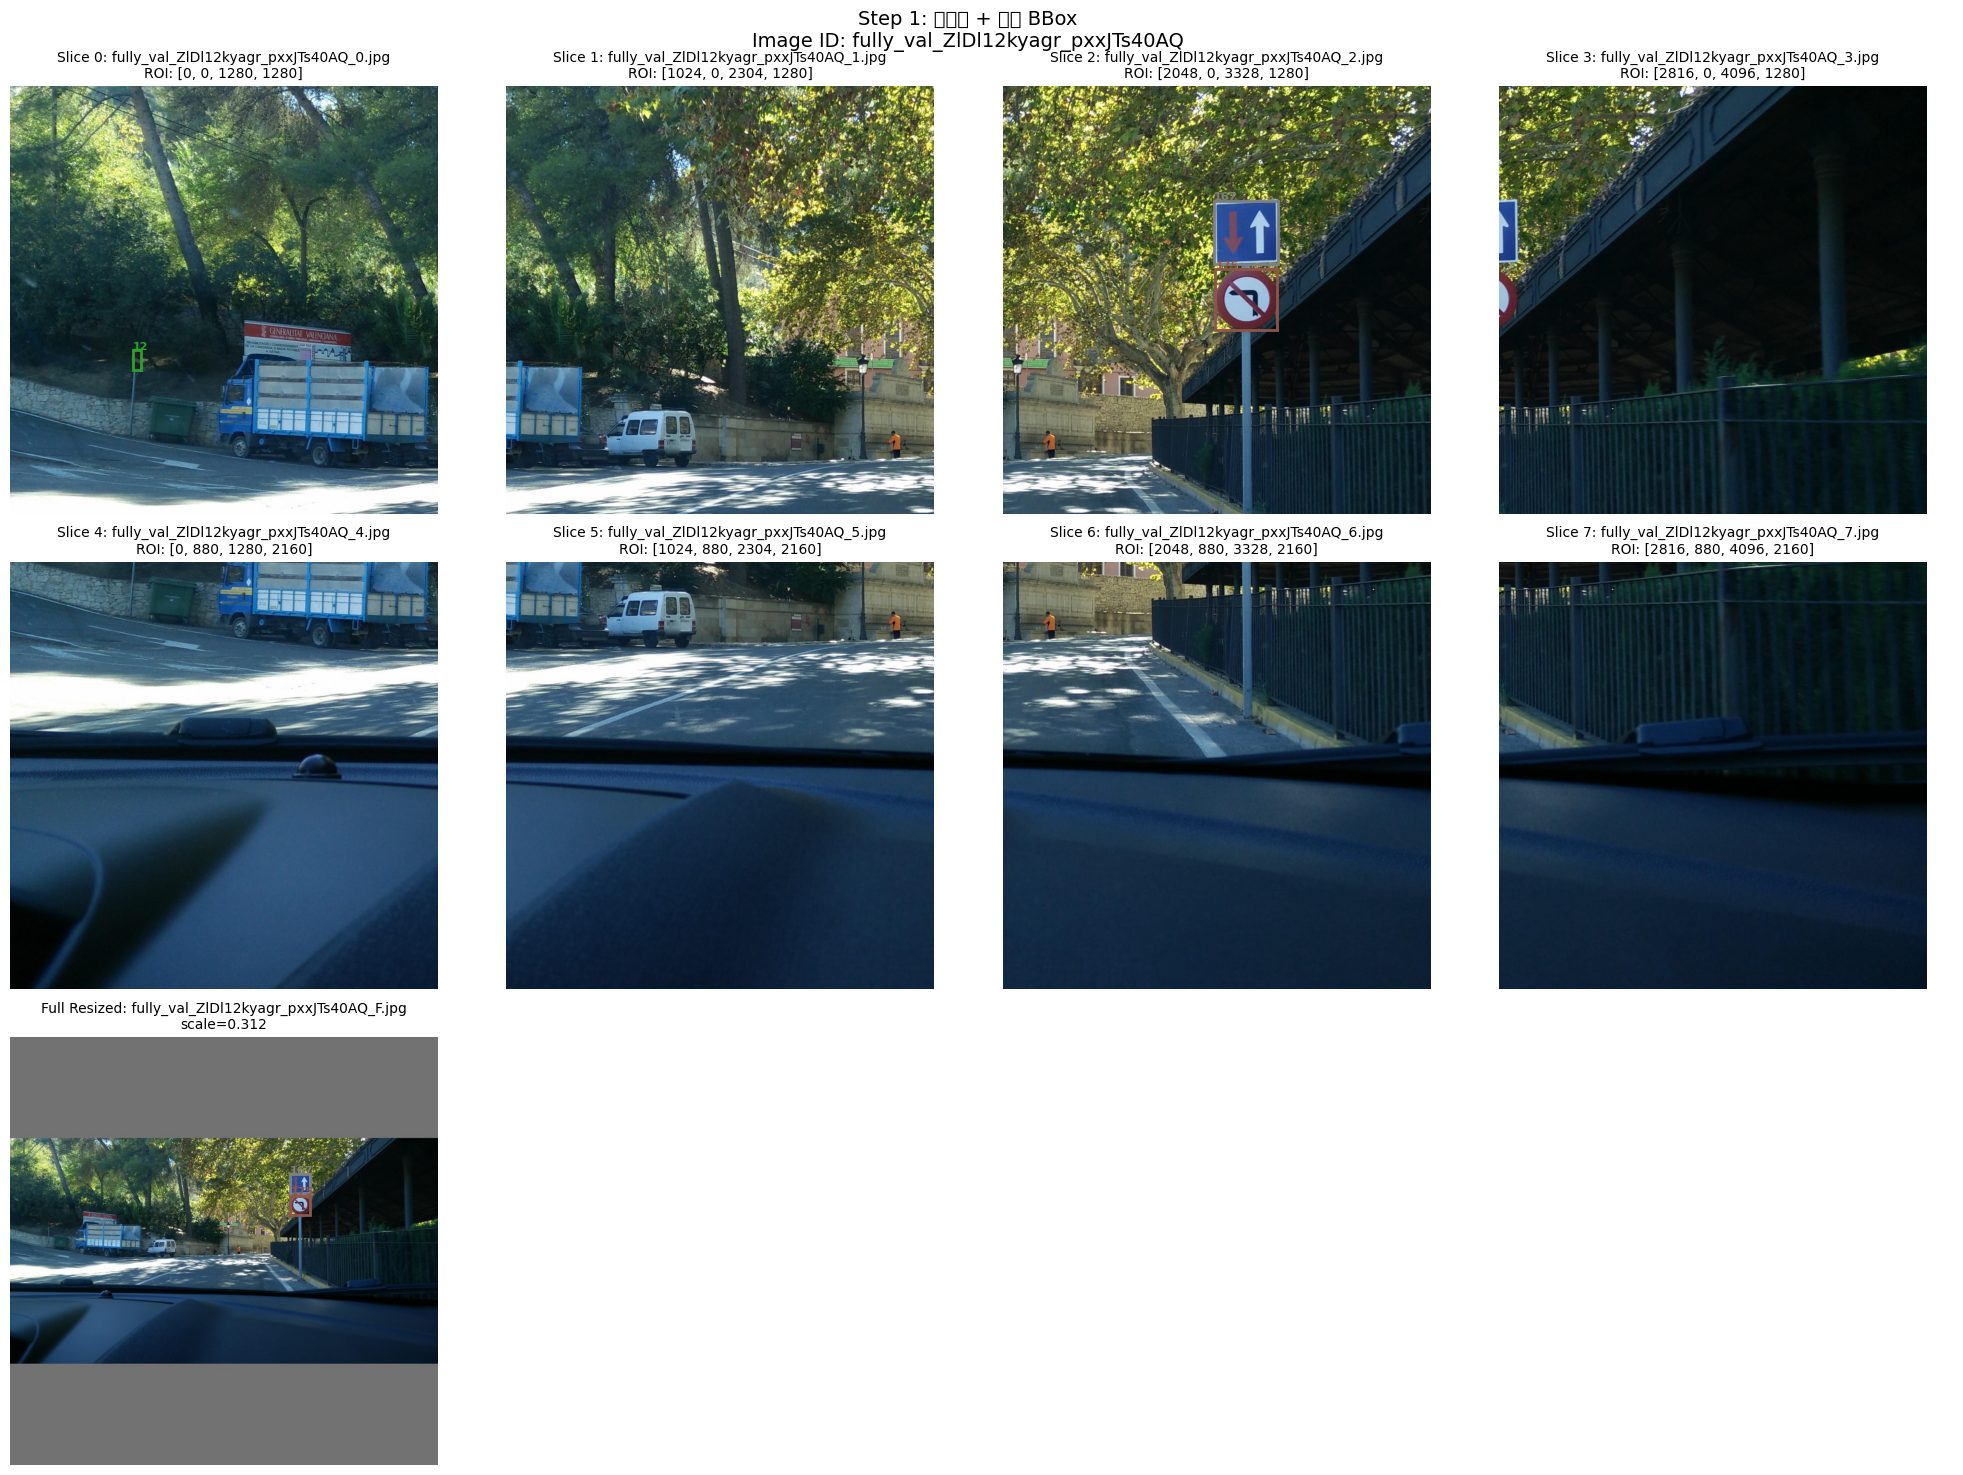

In [28]:
# Step 1: 绘制所有小图（切片）的标注 bbox
slices = index_data["slices"]
full_info = index_data["full_resized"]

n_slices = len(slices) + 1  # +1 for full_resized
ncols = min(4, n_slices)
nrows = (n_slices + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.array(axes).flatten() if n_slices > 1 else [axes]

# 绘制切片
for i, slice_info in enumerate(slices):
    filename = slice_info["filename"]
    roi = slice_info["roi"]
    
    img_path = SLICED_IMAGES_DIR / filename
    label_path = SLICED_LABELS_DIR / filename.replace(".jpg", ".txt")
    
    img = cv2.imread(str(img_path))
    labels = load_yolo_labels(label_path)
    h, w = img.shape[:2]
    
    ax = axes[i]
    draw_bboxes(ax, img, labels, w, h)
    ax.set_title(f"Slice {i}: {filename}\nROI: {roi}", fontsize=10)

# 绘制 full_resized
full_filename = full_info["filename"]
img_path = SLICED_IMAGES_DIR / full_filename
label_path = SLICED_LABELS_DIR / full_filename.replace(".jpg", ".txt")

img = cv2.imread(str(img_path))
labels = load_yolo_labels(label_path)
h, w = img.shape[:2]

ax = axes[len(slices)]
draw_bboxes(ax, img, labels, w, h)
ax.set_title(f"Full Resized: {full_filename}\nscale={full_info['scale_factor']:.3f}", fontsize=10)

# 隐藏多余的子图
for j in range(len(slices) + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"Step 1: 切片图 + 标注 BBox\nImage ID: {image_id}", fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1320469070.py:70: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1320469070.py:70: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1320469070.py:70: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1320469070.py:70: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1320469070.py:70: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh

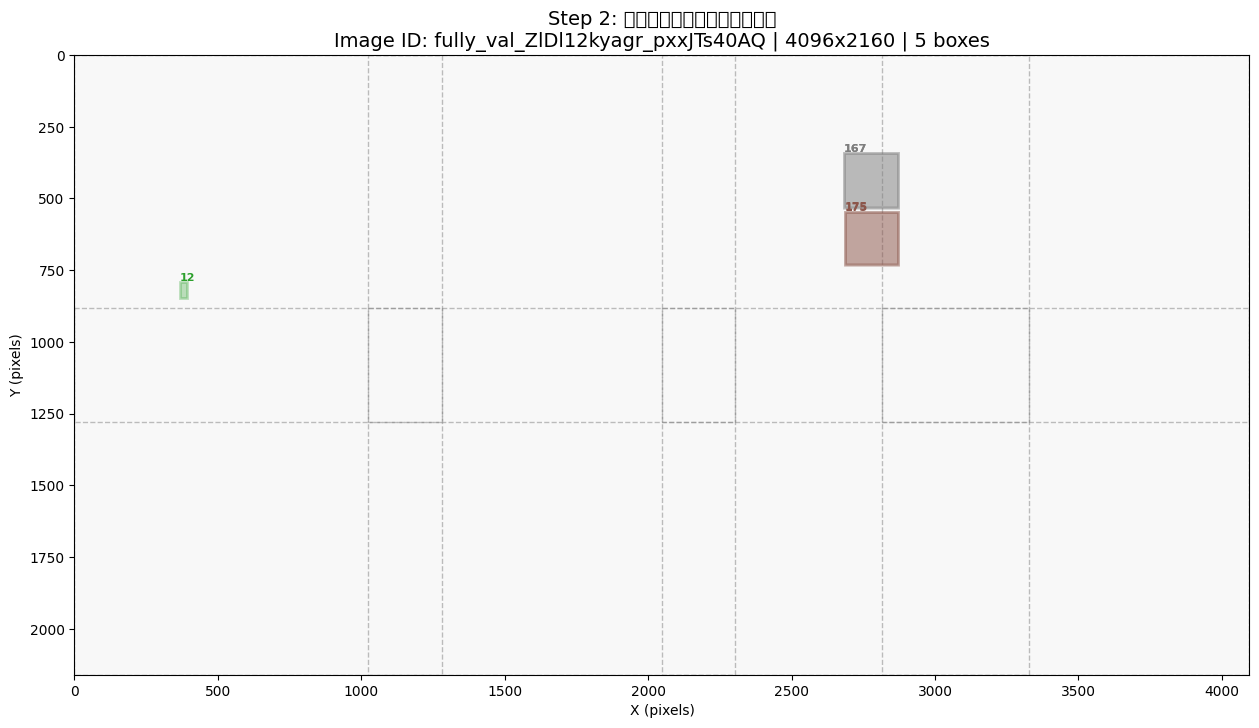

In [29]:
# Step 2: 合成大图上还原的 bbox（从切片标注映射回原图坐标）
orig_h, orig_w = index_data["original_shape"]

# 收集所有切片的 bbox 并映射到原图坐标
all_boxes_xyxy = []

# 从切片收集
for slice_info in index_data["slices"]:
    filename = slice_info["filename"]
    roi = slice_info["roi"]  # [x1, y1, x2, y2]
    label_path = SLICED_LABELS_DIR / filename.replace(".jpg", ".txt")
    labels = load_yolo_labels(label_path)
    
    slice_w = roi[2] - roi[0]
    slice_h = roi[3] - roi[1]
    
    for cls_id, cx, cy, w, h in labels:
        # 转为切片内绝对坐标
        x1_s, y1_s, x2_s, y2_s = yolo_to_xyxy(cx, cy, w, h, slice_w, slice_h)
        # 映射到原图坐标
        x1_o = x1_s + roi[0]
        y1_o = y1_s + roi[1]
        x2_o = x2_s + roi[0]
        y2_o = y2_s + roi[1]
        all_boxes_xyxy.append((cls_id, x1_o, y1_o, x2_o, y2_o))

# 从 full_resized 收集
full_info = index_data["full_resized"]
label_path = SLICED_LABELS_DIR / full_info["filename"].replace(".jpg", ".txt")
labels = load_yolo_labels(label_path)
scale = full_info["scale_factor"]
pad_x, pad_y = full_info["padding"]

for cls_id, cx, cy, w, h in labels:
    # full_resized 是 1280x1280，转为绝对坐标
    x1_r, y1_r, x2_r, y2_r = yolo_to_xyxy(cx, cy, w, h, 1280, 1280)
    # 去掉 padding 并缩放回原图
    x1_o = (x1_r - pad_x) / scale
    y1_o = (y1_r - pad_y) / scale
    x2_o = (x2_r - pad_x) / scale
    y2_o = (y2_r - pad_y) / scale
    all_boxes_xyxy.append((cls_id, x1_o, y1_o, x2_o, y2_o))

# 在空白画布上绘制
fig, ax = plt.subplots(figsize=(14, 14 * orig_h / orig_w))
ax.set_xlim(0, orig_w)
ax.set_ylim(orig_h, 0)
ax.set_facecolor("#f8f8f8")
ax.set_aspect("equal")

# 绘制切片边界（淡色）
for i, slice_info in enumerate(index_data["slices"]):
    x1, y1, x2, y2 = slice_info["roi"]
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=1, edgecolor="gray", facecolor="none", linestyle="--", alpha=0.5)
    ax.add_patch(rect)

# 绘制所有 bbox
colors = plt.cm.tab10.colors
for cls_id, x1, y1, x2, y2 in all_boxes_xyxy:
    color = colors[cls_id % len(colors)]
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor=color, alpha=0.3)
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, str(cls_id), fontsize=8, color=color, fontweight='bold')

ax.set_title(f"Step 2: 合成大图（从切片标注映射）\nImage ID: {image_id} | {orig_w}x{orig_h} | {len(all_boxes_xyxy)} boxes", fontsize=14)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.tight_layout()
plt.show()


/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1251685255.py:12: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9j/s6fh_7n52vn9gdqg0qtbqhlh0000gn/T/ipykernel_31060/1251685255.py:12: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


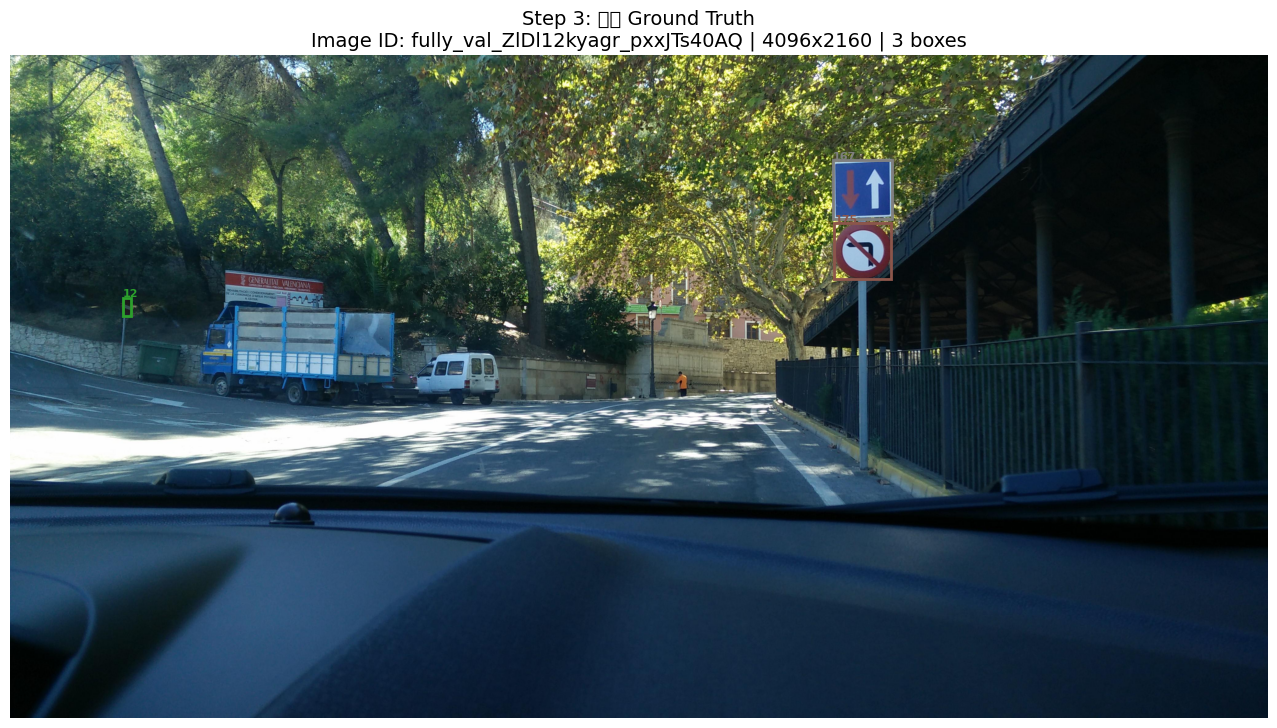


对比统计:
  - 切片映射后 bbox 数量: 5
  - 原图 GT bbox 数量: 3


In [30]:
# Step 3: 原图 + Ground Truth bbox
orig_img_path = ORIGINAL_IMAGES_DIR / f"{image_id}.jpg"
orig_label_path = ORIGINAL_LABELS_DIR / f"{image_id}.txt"

orig_img = cv2.imread(str(orig_img_path))
orig_labels = load_yolo_labels(orig_label_path)
h, w = orig_img.shape[:2]

fig, ax = plt.subplots(figsize=(14, 14 * h / w))
draw_bboxes(ax, orig_img, orig_labels, w, h)
ax.set_title(f"Step 3: 原图 Ground Truth\nImage ID: {image_id} | {w}x{h} | {len(orig_labels)} boxes", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n对比统计:")
print(f"  - 切片映射后 bbox 数量: {len(all_boxes_xyxy)}")
print(f"  - 原图 GT bbox 数量: {len(orig_labels)}")
